<a href="https://colab.research.google.com/github/Rajeraghav/AI-Engineer-Journey/blob/main/Day05/Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Loan-Approval-Prediction.csv to Loan-Approval-Prediction (2).csv
First Five Records
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0    

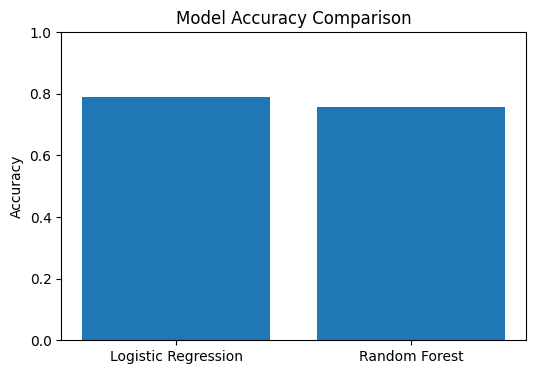



CONFUSION MATRIX
[[18 25]
 [ 5 75]]


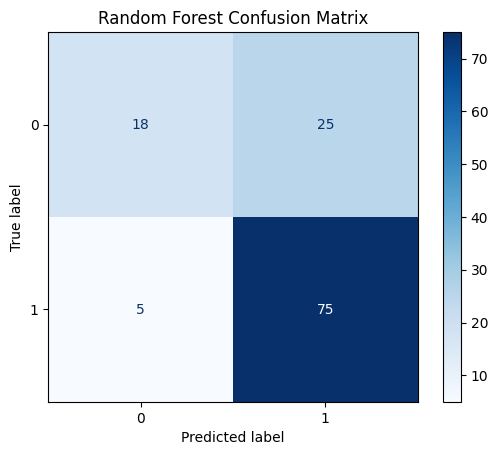



CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



FEATURE IMPORTANCE
              Feature  Importance
9      Credit_History    0.262914
5     ApplicantIncome    0.202666
7          LoanAmount    0.185022
6   CoapplicantIncome    0.113861
8    Loan_Amount_Term    0.051443
10      Property_Area    0.049602
2          Dependents    0.048141
1             Married    0.023648
3           Education    0.021271
0              Gender    0.020718
4       Self_Employed    0.020713


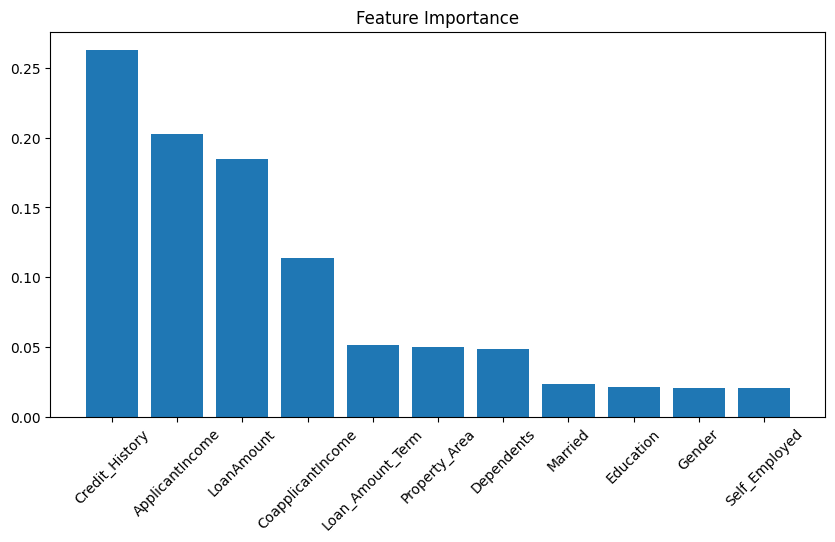


Loan_Approval_Output.csv saved successfully.


PROJECT SUMMARY
Dataset Used          : Loan-Approval-Prediction (2).csv
Total Records         : 614
Logistic Accuracy     : 78.86 %
Random Forest Accuracy: 75.61 %
Best Model            : Logistic Regression


In [3]:
# ==========================================================
# DAY05 - LOAN APPROVAL PREDICTION
# Classification + Data Preprocessing
# Author : Rajeswari P
# ==========================================================

# ==========================
# Step 1 : Upload Dataset
# ==========================

from google.colab import files

uploaded = files.upload()

# Automatically read uploaded file
import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

# ==========================
# Step 2 : Import Libraries
# ==========================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================
# Step 3 : Data Exploration
# ==========================

print("="*60)
print("First Five Records")
print("="*60)

print(df.head())

print("\n")

print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)

print(df.info())

print("\n")

print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum())

print("\n")

print("="*60)
print("Statistical Summary")
print("="*60)

print(df.describe())

# ==========================
# Step 4 : Handle Missing Values
# ==========================

df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Married"] = df["Married"].fillna(df["Married"].mode()[0])

df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])

df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())

df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

print("\nMissing Values After Cleaning")

print(df.isnull().sum())

# ==========================
# Step 5 : Drop Loan_ID
# ==========================

df.drop("Loan_ID", axis=1, inplace=True)

# ==========================
# Step 6 : Label Encoding
# ==========================

encoder = LabelEncoder()

for column in df.columns:

    if df[column].dtype == "object":

        df[column] = encoder.fit_transform(df[column])

# ==========================
# Step 7 : Features & Target
# ==========================

X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

# ==========================
# Step 8 : Feature Scaling
# ==========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================
# Step 9 : Train Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,
    test_size=0.20,
    random_state=42

)

# ==========================
# Step 10 : Logistic Regression
# ==========================

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("\n")

print("="*60)
print("LOGISTIC REGRESSION")
print("="*60)

print("Accuracy :", lr_accuracy)

# ==========================
# Step 11 : Random Forest
# ==========================

rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("\n")

print("="*60)
print("RANDOM FOREST")
print("="*60)

print("Accuracy :", rf_accuracy)

# ==========================
# Step 12 : Accuracy Comparison
# ==========================

plt.figure(figsize=(6,4))

models = [

    "Logistic Regression",

    "Random Forest"

]

accuracies = [

    lr_accuracy,

    rf_accuracy

]

plt.bar(models, accuracies)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

# ==========================
# Step 13 : Confusion Matrix
# ==========================

cm = confusion_matrix(y_test, rf_pred)

print("\n")

print("="*60)
print("CONFUSION MATRIX")
print("="*60)

print(cm)

ConfusionMatrixDisplay(

    confusion_matrix=cm

).plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

# ==========================
# Step 14 : Classification Report
# ==========================

print("\n")

print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(

    y_test,

    rf_pred

))

# ==========================
# Step 15 : Feature Importance
# ==========================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print("\n")

print("="*60)
print("FEATURE IMPORTANCE")
print("="*60)

print(importance)

plt.figure(figsize=(10,5))

plt.bar(

    importance["Feature"],

    importance["Importance"]

)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

# ==========================
# Step 16 : Save Predictions
# ==========================

results = pd.DataFrame({

    "Actual Loan Status": y_test.values,

    "Predicted Loan Status": rf_pred

})

results.to_csv(

    "Loan_Approval_Output.csv",

    index=False

)

print("\nLoan_Approval_Output.csv saved successfully.")

# ==========================
# Step 17 : Final Summary
# ==========================

print("\n")

print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print("Dataset Used          :", filename)

print("Total Records         :", len(df))

print("Logistic Accuracy     :", round(lr_accuracy*100,2), "%")

print("Random Forest Accuracy:", round(rf_accuracy*100,2), "%")

if lr_accuracy > rf_accuracy:
    print("Best Model            : Logistic Regression")
else:
    print("Best Model            : Random Forest")

print("="*60)